
Sinus-Fit für df_1
Amplitude A:       -540.523138 ± 1710456.408848
Frequenz f:        -0.000013 ± 0.021101
Phase φ:           -7.853525 ± 0.749789
Offset:            -491.701966 ± 1710456.505681


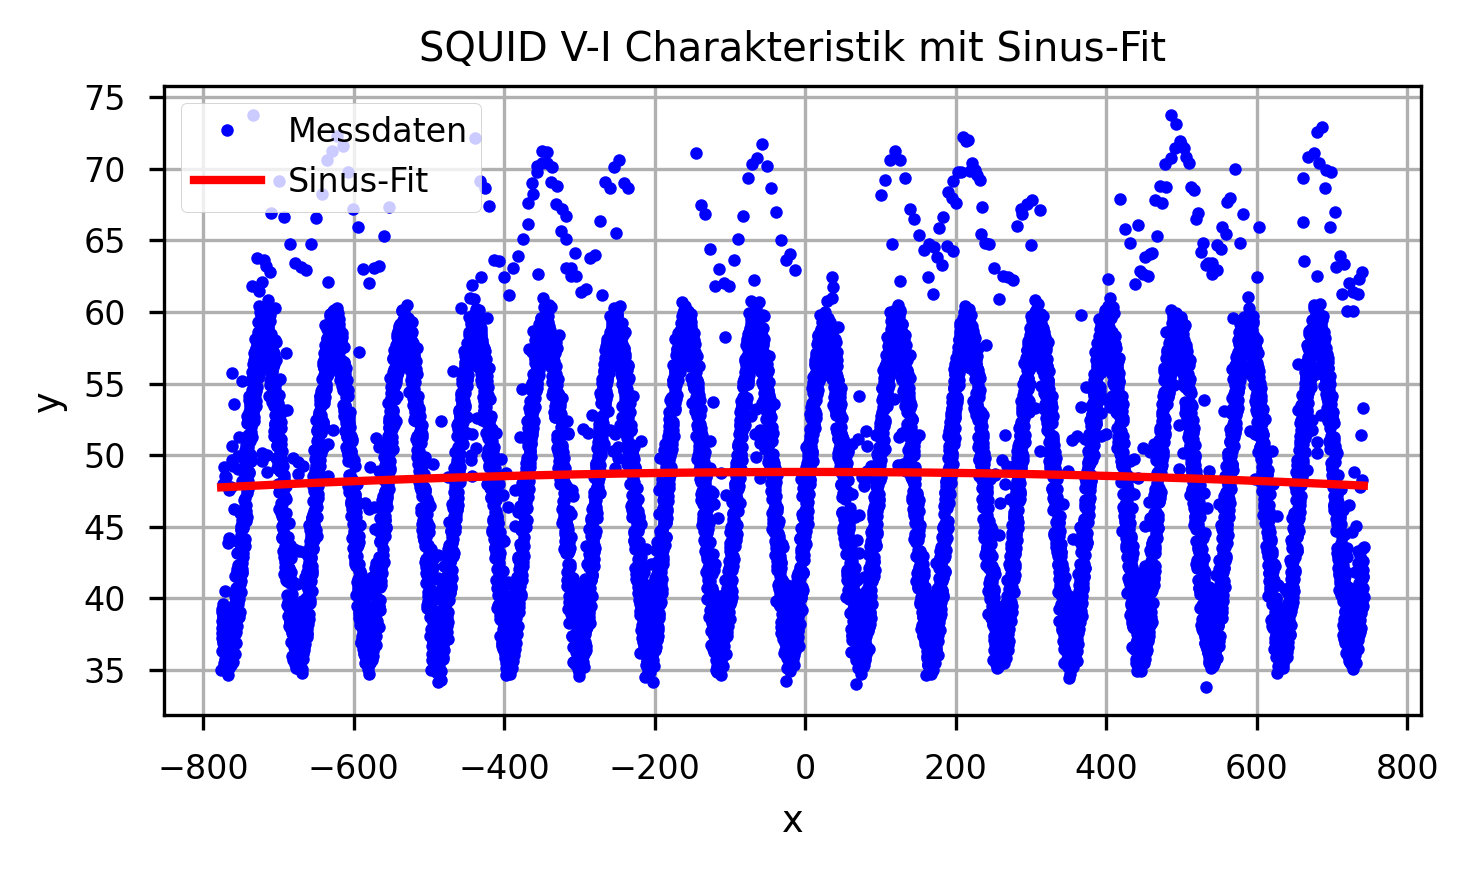


Sinus-Fit für df_2
Amplitude A:       -1032.840888 ± 3757883.583331
Frequenz f:        0.000011 ± 0.019999
Phase φ:           -1.568905 ± 3.555495
Offset:            -983.838387 ± 3757883.688924


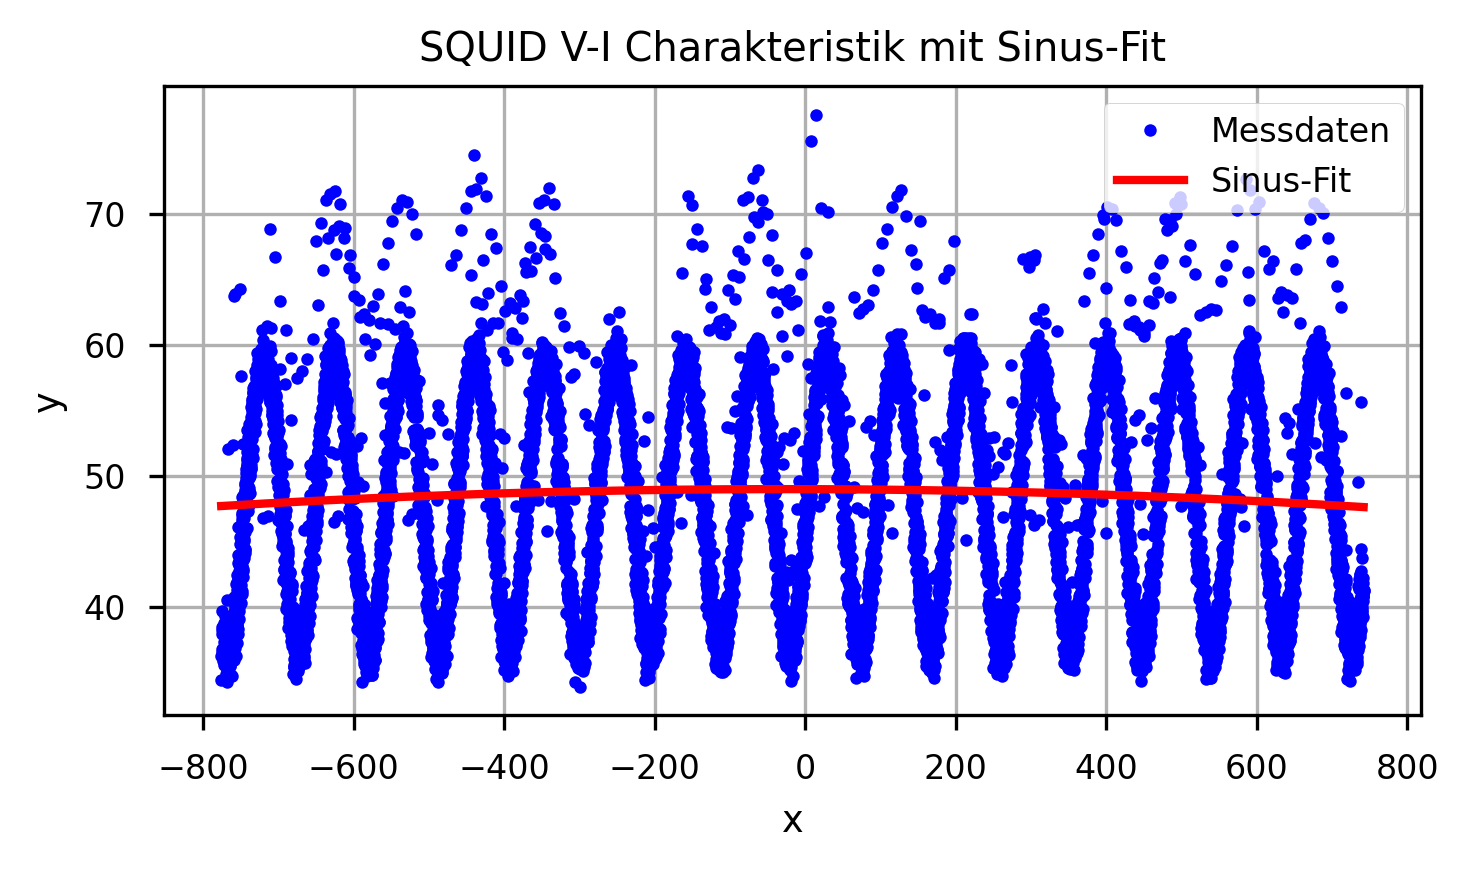


Sinus-Fit für df_3
Amplitude A:       -0.465813 ± 0.162127
Frequenz f:        -0.003308 ± 0.000130
Phase φ:           -2.567147 ± 0.348986
Offset:            49.192237 ± 0.115517


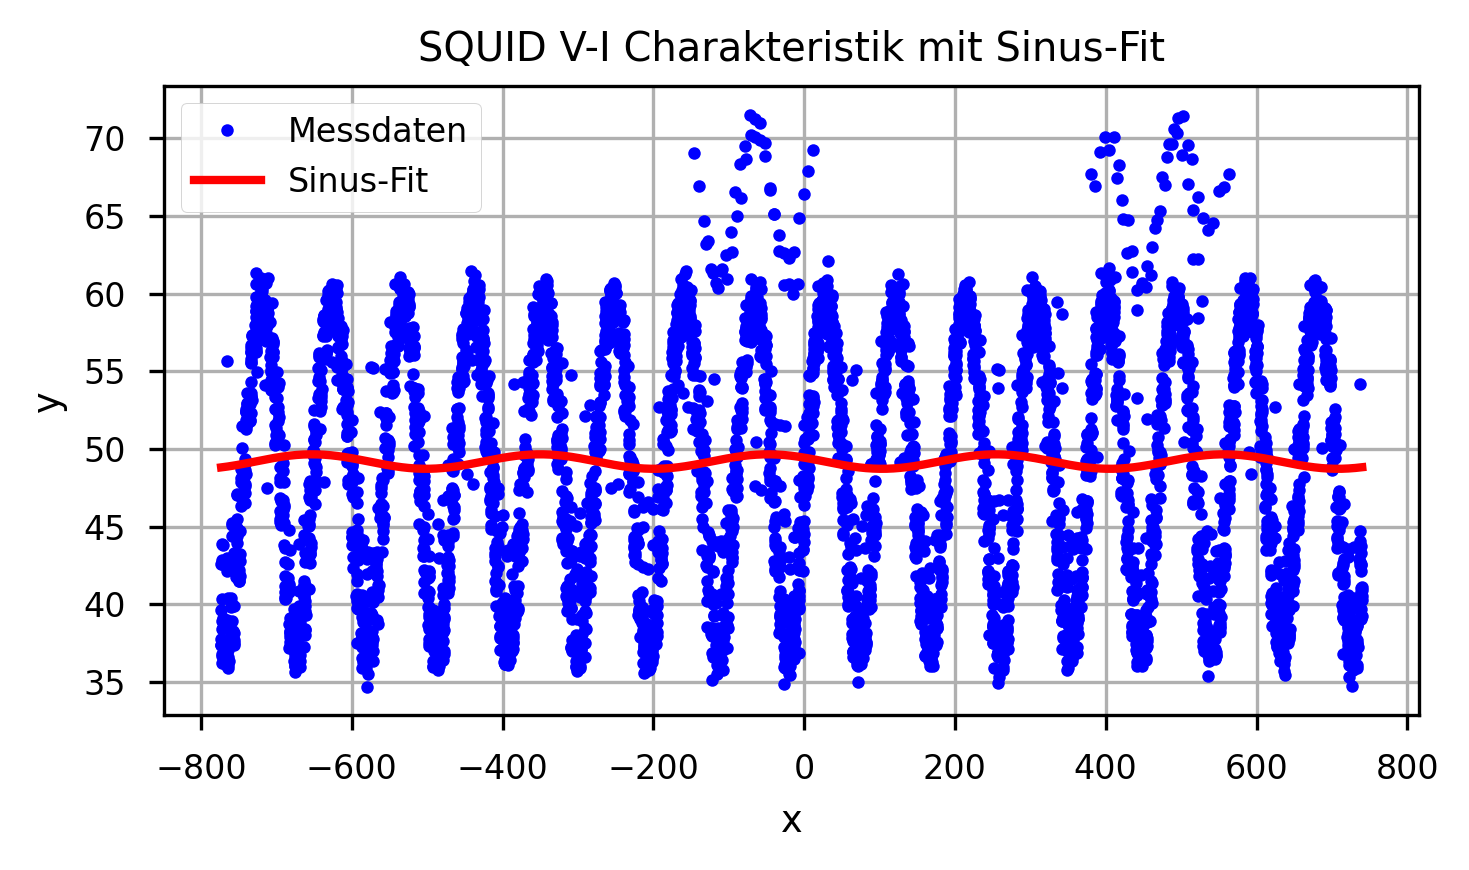


Sinus-Fit für df_4
Amplitude A:       609.118231 ± 2343000.400781
Frequenz f:        -0.000013 ± 0.025632
Phase φ:           7.852612 ± 2.715303
Offset:            -559.511122 ± 2343000.543054


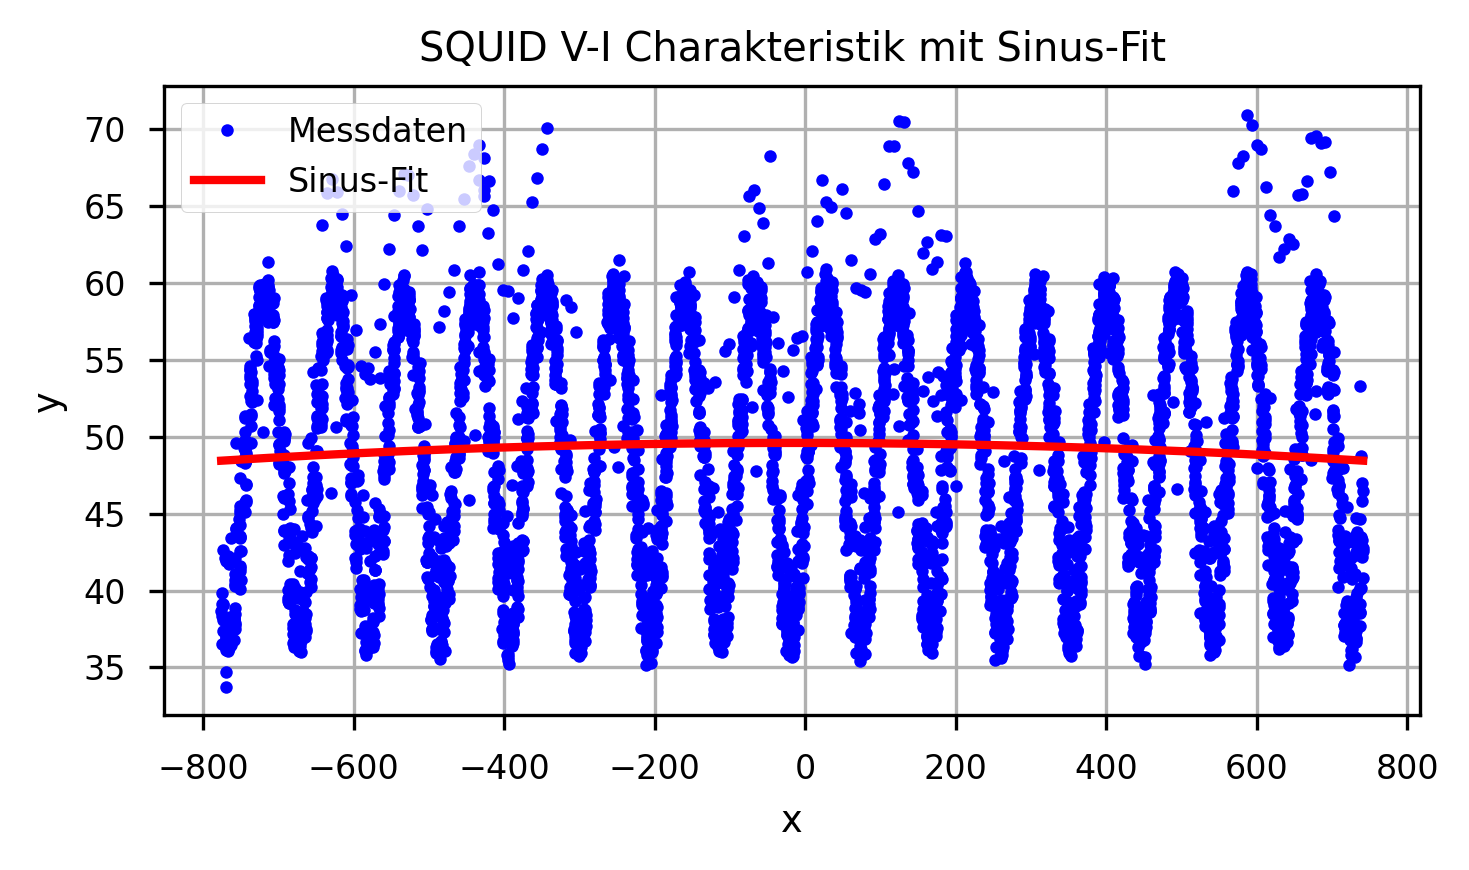


Sinus-Fit für df_5
Amplitude A:       527.844882 ± 2621797.354836
Frequenz f:        0.000009 ± 0.023492
Phase φ:           -1.540586 ± 76.972507
Offset:            630.107079 ± 2621797.217527


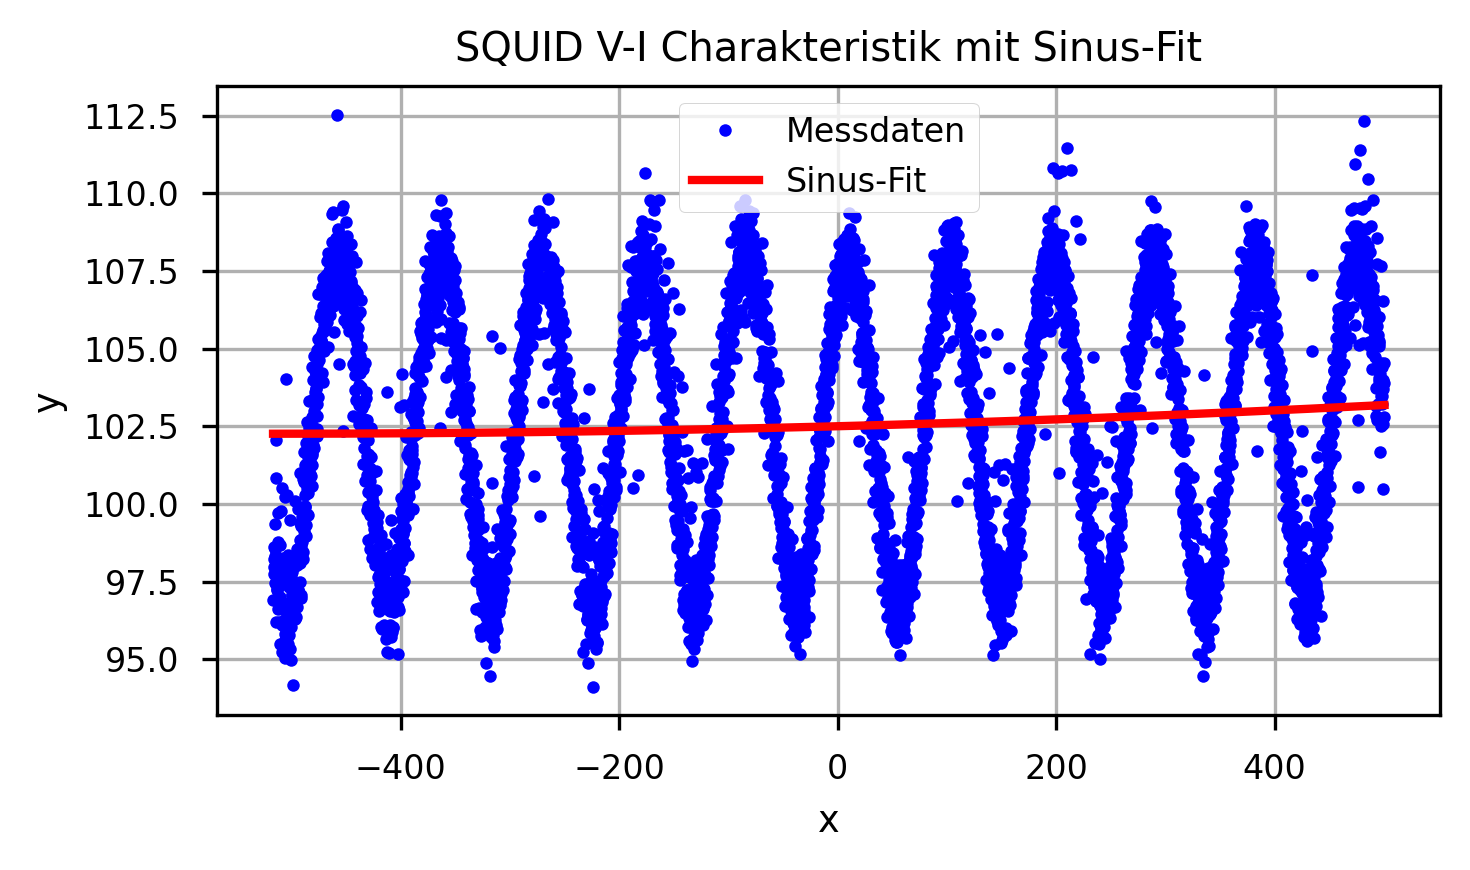


Sinus-Fit für df_6
Amplitude A:       312.388521 ± 1434943.060821
Frequenz f:        0.000010 ± 0.022781
Phase φ:           -1.520816 ± 117.407342
Offset:            414.502207 ± 1434942.163748


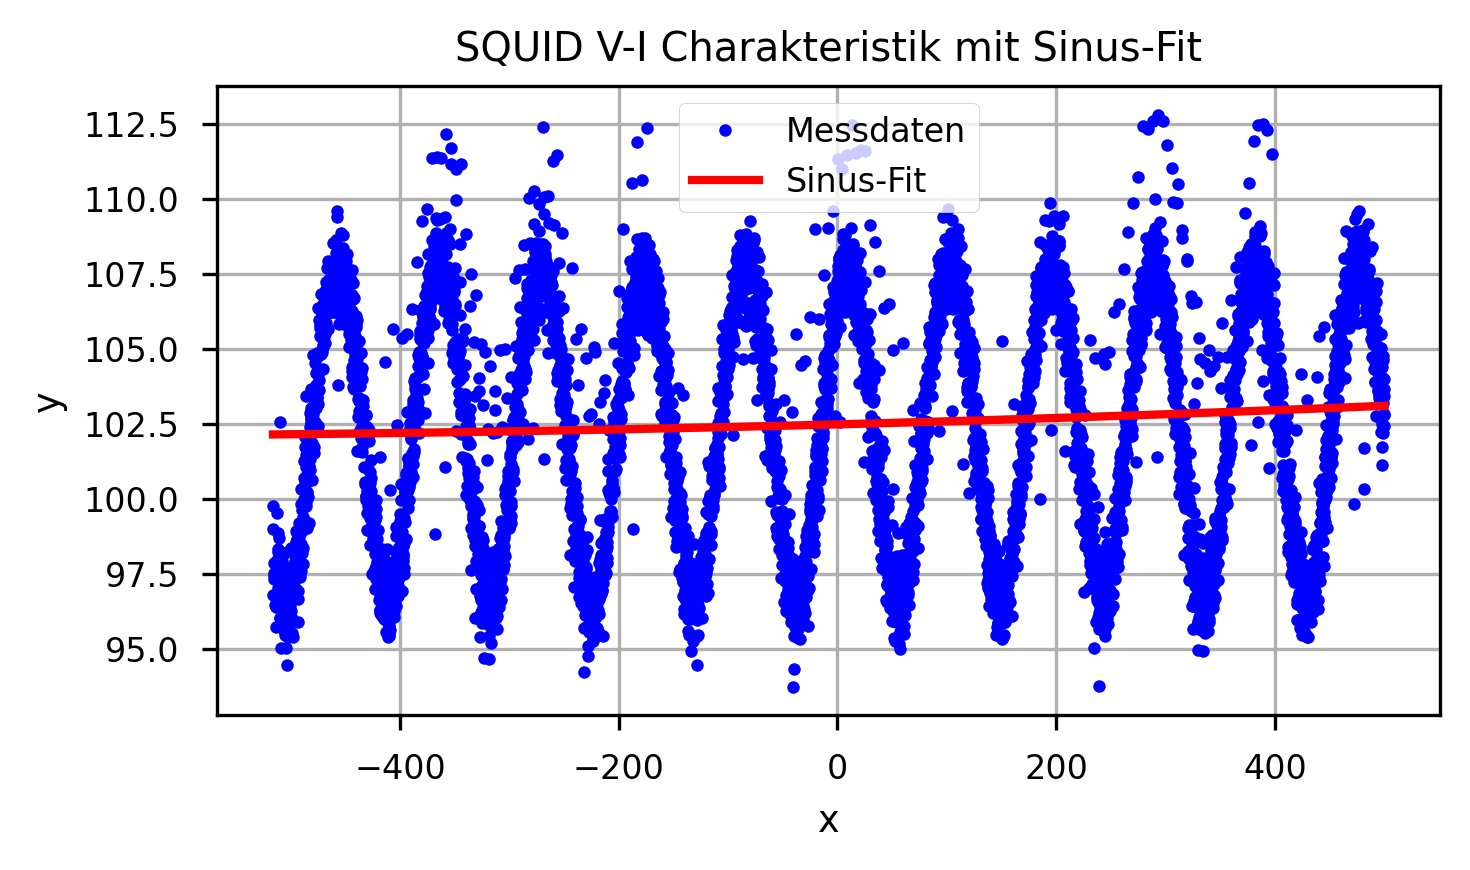

In [2]:
from matplotlib import rcParams
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.style as mtlstyle

from scipy.optimize import curve_fit

mtlstyle.use("seaborn-v0_8-paper")

rcParams["figure.dpi"] = 300
rcParams["figure.figsize"] = (5, 3)

# Sinus-Fit Funktion
def sine_function(x, A, f, phi, offset):
    """Sinus-Funktion: A*sin(2*pi*f*x + phi) + offset"""
    return A * np.sin(2 * np.pi * f * x + phi) + offset

# CSV einlesen
df_1 = pd.read_csv('10_26_2011-07_50_08_1s_biggest.csv')
df_1.columns = df_1.columns.str.replace('"', '').str.strip()
df_2 = pd.read_csv('10_26_2011-07_49_48_1s_biggest.csv')
df_2.columns = df_2.columns.str.replace('"', '').str.strip()
df_3 = pd.read_csv('10_26_2011-07_48_07_0_5s_biggest.csv')
df_3.columns = df_3.columns.str.replace('"', '').str.strip()
df_4 = pd.read_csv('10_26_2011-07_48_04_0_5s_biggest.csv')
df_4.columns = df_4.columns.str.replace('"', '').str.strip()
df_5 = pd.read_csv('10_26_2011-07_43_03_FLL_1.csv')
df_5.columns = df_5.columns.str.replace('"', '').str.strip()
df_6 = pd.read_csv('10_26_2011-07_42_14_Internal_flux_0_shapiro_stufen_4.csv')
df_6.columns = df_6.columns.str.replace('"', '').str.strip()

# Liste mit allen DataFrames
dfs = [df_1, df_2, df_3, df_4, df_5, df_6]
labels = ["df_1", "df_2", "df_3", "df_4", "df_5", "df_6"]

# Funktion zum Plotten und Fitten
def plot_and_fit(df, label):
    x_data = df['0_x'].values
    y_data = df['0_y'].values
    
    # Initiale Parameterschätzung
    A_init = (np.max(y_data) - np.min(y_data)) / 2
    offset_init = 2
    f_init = 1 / (2 * (np.max(x_data) - np.min(x_data)))
    
    try:
        # Curve fit
        popt, pcov = curve_fit(sine_function, x_data, y_data, 
                               p0=[A_init, f_init, 0, offset_init],
                               maxfev=10000)
        
        # Standardabweichungen berechnen
        perr = np.sqrt(np.diag(pcov))
        
        # Parameter auspacken
        A, f, phi, offset = popt
        A_err, f_err, phi_err, offset_err = perr
        
        # Ergebnisse drucken
        print(f"\n{'='*60}")
        print(f"Sinus-Fit für {label}")
        print(f"{'='*60}")
        print(f"Amplitude A:       {A:.6f} ± {A_err:.6f}")
        print(f"Frequenz f:        {f:.6f} ± {f_err:.6f}")
        print(f"Phase φ:           {phi:.6f} ± {phi_err:.6f}")
        print(f"Offset:            {offset:.6f} ± {offset_err:.6f}")
        print(f"{'='*60}")
        
        # Plot
        plt.figure()
        plt.plot(x_data, y_data, label="Messdaten", color="blue", 
                linewidth=0, marker='o', markersize=3)
        
        # Fit-Linie plotten
        x_smooth = np.linspace(np.min(x_data), np.max(x_data), 500)
        y_fit = sine_function(x_smooth, *popt)
        plt.plot(x_smooth, y_fit, label="Sinus-Fit", color="red", linewidth=2)
        
        plt.xlabel("x")
        plt.ylabel("y")
        plt.title("SQUID V-I Charakteristik mit Sinus-Fit")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()
        
        return popt, perr
        
    except Exception as e:
        print(f"\nFehler beim Fitting von {label}: {e}")
        return None, None

# Alle Plots mit Fit
for df, label in zip(dfs, labels):
    plot_and_fit(df, label)
